# Week 11 - Introduction to Modeling, part 2

# 1. Lesson - No lesson this week

# 2. Weekly graph question

In [1]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import root_mean_squared_error
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import make_scorer

The book names one of Vonnegut's rules as "keep it simple" and another as "have the guts to cut."  Here is some data from the previous week's lesson.  If you had to cut one of the two plots below, which would it be?  Which seems more interesting or important?  Explain.  (Should "amount of training data used" or "number of estimators" be on the x-axis.)

In [2]:
np.random.seed(0)
num_points = 10000
feature_1a = np.random.random(size = num_points) * 3
feature_2a = np.random.random(size = num_points) * 3
feature_3a = np.random.random(size = num_points) * 3
train_target = (feature_1a - 2 * feature_2a) * feature_3a + np.random.normal(size = num_points)
feature_1b = np.random.random(size = num_points) * 3
feature_2b = np.random.random(size = num_points) * 3
feature_3b = np.random.random(size = num_points) * 3
test_target = (feature_1b - 2 * feature_2b) * feature_3b + np.random.normal(size = num_points)
train_df = pd.DataFrame({"f1": feature_1a, "f2": feature_2a, "f3": feature_3a})
test_df = pd.DataFrame({"f1": feature_1b, "f2": feature_2b, "f3": feature_3b})
rf = RandomForestRegressor()
rf.fit(train_df.values, train_target)

RandomForestRegressor()

In [3]:
rmse_lst = list()
rf = RandomForestRegressor()
for x in range(round(num_points / 20), num_points, round(num_points / 20)):
    rf.fit(train_df.values[0:x,:], train_target[0:x])
    rmse_lst.append(root_mean_squared_error(rf.predict(test_df.values), test_target))

import matplotlib.pyplot as plt

Text(0, 0.5, 'Loss function')

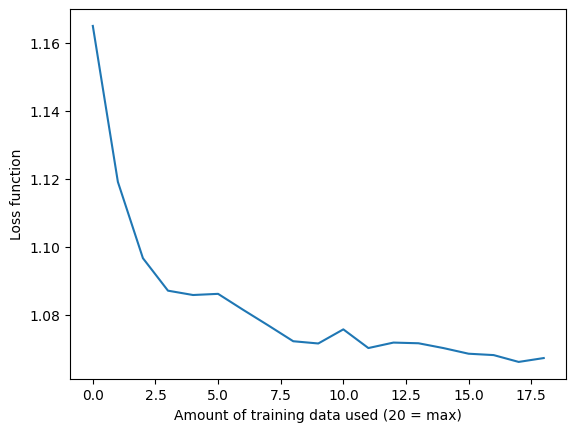

In [4]:
plt.plot(rmse_lst)
plt.xlabel("Amount of training data used (20 = max)")
plt.ylabel("Loss function")

In [5]:
num_trees_lst = list()
for n_estimators in range(1, 100, 3):
    rf = RandomForestRegressor(n_estimators = n_estimators)
    rf.fit(train_df.values, train_target)
    num_trees_lst.append(root_mean_squared_error(rf.predict(test_df.values), test_target))

Text(0, 0.5, 'Loss function')

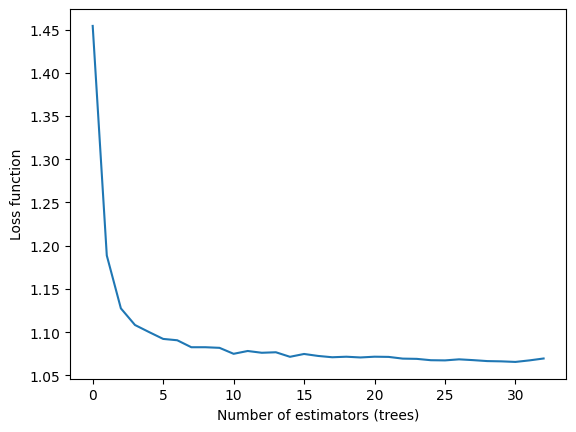

In [15]:
plt.plot(num_trees_lst)
plt.xlabel("Number of estimators (trees)")
plt.ylabel("Loss function")

I would cut the “number of estimators” plot because it shows improvement in loss early on but the curve flattens quickly. This means it’s mainly a tuning detail. The “amount of training data used” plot is more informative because it helps decide whether collecting more data is worth it and that is a more important takeaway for understanding model performance.

# 3. Working on your datasets

This week, you will do the same types of exercises as last week, but you should use your chosen datasets that someone in your class found last semester. (They likely will not be the particular datasets that you found yourself.)

Here are some types of analysis you can do:

* Implement a random forest model.
* Perform cross-validation.
* Tune hyperparameters.
* Evaluate a performance metric.

If you like, you can try other types of models, too (beyond linear regression and random forest) although you will have many opportunities to do that next semester.

In [6]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier

# Load
df = pd.read_csv("hypertension_dataset.csv")
target_col = "Hypertension"

# Target to 0/1 if it is text
y = df[target_col].replace({"yes":1, "no":0, "Yes":1, "No":0, "Y":1, "N":0})
if y.dtype == "O":
    y = pd.factorize(y)[0]

X = df.drop(columns=[target_col])

# Preprocess
num_cols = X.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = X.select_dtypes(exclude=[np.number]).columns.tolist()

preprocess = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat_cols),
        ("num", "passthrough", num_cols),
    ]
)

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Pipeline with Random Forest
rf_pipe = Pipeline(steps=[
    ("prep", preprocess),
    ("rf", RandomForestClassifier(random_state=42, n_estimators=200))
])

rf_pipe.fit(X_train, y_train)


Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False),
                                                  ['Country', 'Smoking_Status',
                                                   'Physical_Activity_Level',
                                                   'Family_History', 'Diabetes',
                                                   'Gender', 'Education_Level',
                                                   'Employment_Status']),
                                                 ('num', 'passthrough',
                                                  ['Age', 'BMI', 'Cholesterol',
                                                   'Systolic_BP',
                                                   'Diastolic_BP',
                                                   'Alcohol_Intake',
                                                   'Stress_Level',
                                                   'Salt_Intake',
                                                   'Sleep_Duration',
                                                   'Heart_Rate', 'LDL', 'HDL',
                                                   'Triglycerides',
                                                   'Glucose'])])),
                ('rf',
                 RandomForestClassifier(n_estimators=200, random_state=42))])

In [7]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_acc = cross_val_score(rf_pipe, X_train, y_train, cv=cv, scoring="accuracy", n_jobs=-1)
print("CV accuracy mean:", cv_acc.mean(), "std:", cv_acc.std())

# Optional (binary only): AUC as a second metric
try:
    cv_auc = cross_val_score(rf_pipe, X_train, y_train, cv=cv, scoring="roc_auc", n_jobs=-1)
    print("CV ROC AUC mean:", cv_auc.mean(), "std:", cv_auc.std())
except Exception as e:
    print("AUC not computed:", e)


CV accuracy mean: 0.7188198735578812 std: 1.428724506196133e-05
CV ROC AUC mean: 0.4990770753418773 std: 0.0037557821276351508


In [8]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "rf__n_estimators": [200, 400],
    "rf__max_depth": [None, 10, 20],
    "rf__min_samples_split": [2, 5],
    "rf__min_samples_leaf": [1, 2],
}

grid = GridSearchCV(
    rf_pipe,
    param_grid=param_grid,
    scoring="accuracy",   # swap to "f1" if classes are imbalanced
    cv=3,
    n_jobs=-1,
    verbose=1
)
grid.fit(X_train, y_train)

print("Best params:", grid.best_params_)
print("Best CV score:", grid.best_score_)

best_model = grid.best_estimator_

Fitting 3 folds for each of 24 candidates, totalling 72 fits


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/joblib/externals/loky/process_executor.py:752: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Best params: {'rf__max_depth': None, 'rf__min_samples_leaf': 1, 'rf__min_samples_split': 2, 'rf__n_estimators': 200}
Best CV score: 0.7188198735802147


Baseline test accuracy: 0.7188330428322428
Baseline report:
               precision    recall  f1-score   support

           0       0.72      1.00      0.84     25157
           1       0.00      0.00      0.00      9840

    accuracy                           0.72     34997
   macro avg       0.36      0.50      0.42     34997
weighted avg       0.52      0.72      0.60     34997



/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  

Tuned test accuracy: 0.7188330428322428
Tuned report:
               precision    recall  f1-score   support

           0       0.72      1.00      0.84     25157
           1       0.00      0.00      0.00      9840

    accuracy                           0.72     34997
   macro avg       0.36      0.50      0.42     34997
weighted avg       0.52      0.72      0.60     34997



/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  

Tuned test ROC AUC: 0.5092388862981129


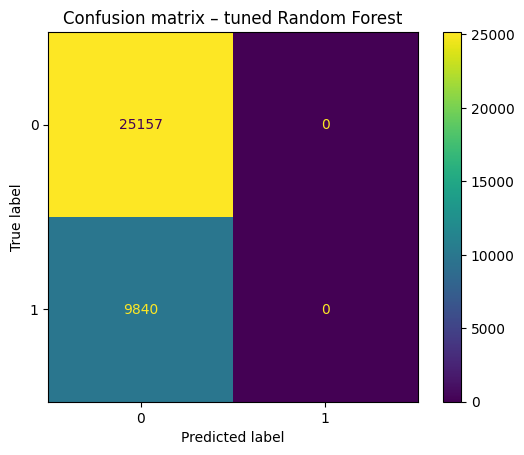

In [9]:
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Baseline (untuned) test metrics
y_pred_base = rf_pipe.predict(X_test)
print("Baseline test accuracy:", accuracy_score(y_test, y_pred_base))
print("Baseline report:\n", classification_report(y_test, y_pred_base))

# Tuned model test metrics
y_pred = best_model.predict(X_test)
print("Tuned test accuracy:", accuracy_score(y_test, y_pred))
print("Tuned report:\n", classification_report(y_test, y_pred))

try:
    y_proba = best_model.predict_proba(X_test)[:, 1]
    print("Tuned test ROC AUC:", roc_auc_score(y_test, y_proba))
except Exception:
    pass

ConfusionMatrixDisplay.from_estimator(best_model, X_test, y_test)
plt.title("Confusion matrix – tuned Random Forest")
plt.show()

# 4. Storytelling With Data plot

Reproduce any graph of your choice in chapter seven (p. 165-185) of the Storytelling With Data book as best you can. You do not have to get the exact data values right, just the overall look and feel.

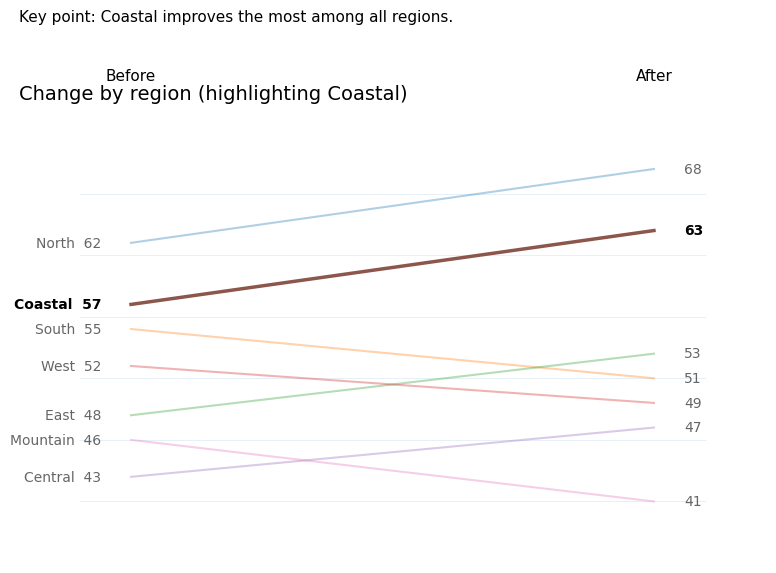

In [10]:
import matplotlib.pyplot as plt
import numpy as np

cats = ["North", "South", "East", "West", "Central", "Coastal", "Mountain"]
before = np.array([62, 55, 48, 52, 43, 57, 46])
after  = np.array([68, 51, 53, 49, 47, 63, 41])

# Choose one category to highlight
highlight_label = "Coastal"

# Plot setup
plt.figure(figsize=(8, 6))
ax = plt.gca()
ax.set_xlim(0, 1)
ax.set_ylim(min(before.min(), after.min()) - 5, max(before.max(), after.max()) + 5)

for spine in ["top", "right", "left", "bottom"]:
    ax.spines[spine].set_visible(False)
ax.set_xticks([])
ax.set_yticks([])

# Light guide lines
for y in range(int(ax.get_ylim()[0]) + 5, int(ax.get_ylim()[1]) - 4, 5):
    ax.hlines(y, 0.08, 0.92, lw=0.5, alpha=0.15)

# Draw lines and labels
for i, c in enumerate(cats):
    x0, x1 = 0.15, 0.85
    y0, y1 = before[i], after[i]
    is_highlight = (c == highlight_label)

    ax.plot([x0, x1], [y0, y1],
            linewidth=2.5 if is_highlight else 1.5,
            alpha=1.0 if is_highlight else 0.35)

    # Left labels (before)
    ax.text(x0 - 0.04, y0, f"{c}  {before[i]}",
            ha="right", va="center",
            fontsize=10,
            weight="bold" if is_highlight else "normal",
            alpha=1.0 if is_highlight else 0.6)

    # Right labels (after)
    ax.text(x1 + 0.04, y1, f"{after[i]}",
            ha="left", va="center",
            fontsize=10,
            weight="bold" if is_highlight else "normal",
            alpha=1.0 if is_highlight else 0.6)

ax.text(0.15, ax.get_ylim()[1] + 2, "Before", ha="center", va="bottom", fontsize=11)
ax.text(0.85, ax.get_ylim()[1] + 2, "After",  ha="center", va="bottom", fontsize=11)

plt.title("Change by region (highlighting Coastal)", loc="left", fontsize=14)
plt.suptitle("")  
ax.text(0.0, ax.get_ylim()[1] + 7,
        "Key point: Coastal improves the most among all regions.",
        fontsize=11, ha="left")

plt.tight_layout()
plt.show()